# XBPASS LX-SFR Relationship

Use the our implementation of the XBPASS models to calculate $L_X$ for a variety of SFR and SFHs. Since the XBPASS models are postprocessed to reproduce some empirical scaling relations, we should expect decent agreement. However, note that I'm just sampling random SFHs and not using realistic SFHs. 

## Imports

In [13]:
import numpy as np
from lightning import Lightning
import astropy.units as u
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
from corner import corner
import matplotlib.pyplot as plt
plt.style.use('lightning.plots.style.lightning-serif')
%matplotlib inline
from lightning.stellar import BPASSModelA24, BPASSBurstA24
from lightning.priors import UniformPrior, ConstantPrior
from lightning.sfh import PiecewiseConstSFH

In [2]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
redshift = 0.0
univ_age = cosmo.age(redshift).value
age = np.array([0, 1.0e7, 1.0e8, 1.0e9, 5e9, univ_age * 1e9])
filter_labels = ['SDSS_u']

In [3]:
bp = BPASSModelA24(
    filter_labels, redshift, age=age, XBPASS=True
)

In [8]:
bp.print_params(verbose=True)


BPASS-Stellar-A24
Parameter     Lo   Hi                                                   Description
--------- ------ ---- -------------------------------------------------------------
     Zmet 0.0001 0.04 Metallicity (mass fraction, where solar = 0.020 ~ 10**[-1.7])
     logU   -4.0 -1.5                             log10 of the ionization parameter

Total parameters: 2


## LX vs SFR

We make a few random SFHs for star-forming galaxies (less than 1 solar mass per year of star formation) and plot LX as a function of SFR

In [4]:
sfh = PiecewiseConstSFH(age)

sfh_dists = [
    UniformPrior([0,1]),
    UniformPrior([0,1]),
    UniformPrior([0,0.1]),
    UniformPrior([0,0.1]),
    UniformPrior([0,0.1]),
]

sfh_params = np.stack(
    [p.sample(1000) for p in sfh_dists],
    axis=-1
)

print(sfh_params.shape)

(1000, 5)


In [5]:
stellar_params = np.tile(
    [0.02, -2.0],
    reps=(1000, 1)
)

print(stellar_params.shape)       

(1000, 2)


In [6]:
LX = bp.get_model_LX(
    sfh, 
    sfh_params, 
    stellar_params
)
print(LX.shape)

(1000, 3)


[9.34646077e+38 1.17606175e+39 1.82361722e+39]


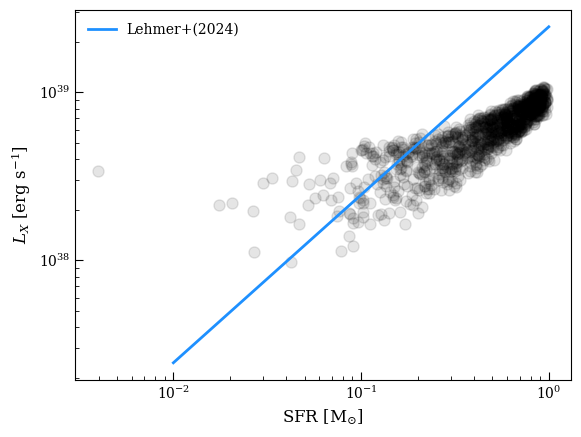

In [7]:
fig,ax = plt.subplots()
sfr = 0.1 * sfh_params[:,0] + 0.9 * sfh_params[:,1]

ax.scatter(
    sfr,
    LX[:,2] * 3.848e33,
    marker='o',
    facecolor='k',
    s=64,
    alpha=0.1
)

ax.plot(
    np.array([0.01, 1.0]),
    10**(39.39)*(np.array([0.01, 1.0])),
    color='dodgerblue',
    linewidth=2,
    label='Lehmer+(2024)'
)

ax.set_xlabel(r'SFR [$\rm M_{\odot}$]')
ax.set_ylabel(r'$L_X~[\rm erg~s^{-1}]$')

ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(loc='upper left')

print(
    np.quantile(
        LX[:,2] * 3.848e33 / sfr,
        q=(0.16, 0.50, 0.84)
    )
)

## LX/SFR vs. sSFR

For low sSFR galaxies, we observe an additional dependence of LX/SFR on (sSFR)$^{-1}$.
Here we make a few random low sSFR SFHs and plot them together with the original set as a function of sSFR.

In [8]:
oldsfh_dists = [
    UniformPrior([0,0.1]),
    UniformPrior([0,0.1]),
    UniformPrior([0,1]),
    UniformPrior([0,1]),
    UniformPrior([0,1]),
]

oldsfh_params = np.stack(
    [p.sample(1000) for p in oldsfh_dists],
    axis=-1
)

In [9]:
LX_old = bp.get_model_LX(
    sfh, 
    oldsfh_params, 
    stellar_params
)

[9.34646077e+38 1.17606175e+39 1.82361722e+39]
[2.20070104e+40 4.60682386e+40 1.15345856e+41]


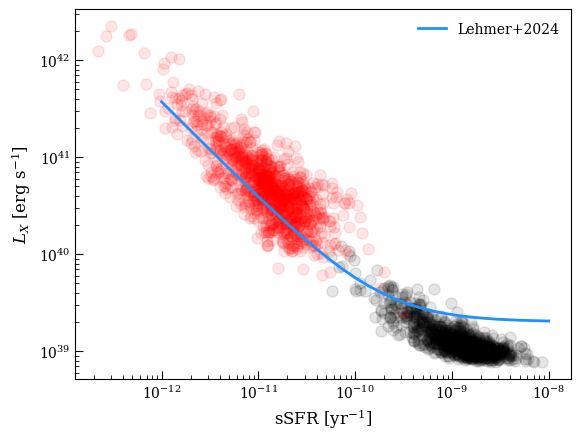

In [11]:
fig,ax = plt.subplots()
sfr = 0.1 * sfh_params[:,0] + 0.9 * sfh_params[:,1]
oldsfr = 0.1 * oldsfh_params[:,0] + 0.9 * oldsfh_params[:,1]
mstar = np.sum(
    bp.get_mstar_coeff(stellar_params[:,0]) * sfh_params,
    axis=1
)
oldmstar = np.sum(
    bp.get_mstar_coeff(stellar_params[:,0]) * oldsfh_params,
    axis=1
)
ssfr = sfr / mstar
oldssfr = oldsfr / oldmstar


ax.scatter(
    ssfr,
    LX[:,2] * 3.848e33 / sfr,
    marker='o',
    facecolor='k',
    s=64,
    alpha=0.1
)
ax.scatter(
    oldssfr,
    LX_old[:,2] * 3.848e33 / oldsfr,
    marker='o',
    facecolor='red',
    s=64,
    alpha=0.1
)

ssfrvals = np.logspace(-12, -8, 31)

ax.plot(
    ssfrvals,
    10**29.57 * (1/ssfrvals) + 10**39.303,
    color='dodgerblue',
    label='Lehmer+2024',
    linewidth=2
)

ax.set_xlabel(r'sSFR [$\rm yr^{-1}$]')
ax.set_ylabel(r'$L_X~[\rm erg~s^{-1}]$')

ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(loc='upper right')

print(
    np.quantile(
        LX[:,2] * 3.848e33 / sfr,
        q=(0.16, 0.50, 0.84)
    )
)
print(
    np.quantile(
        LX_old[:,2] * 3.848e33 / oldsfr,
        q=(0.16, 0.50, 0.84)
    )
)

## LX-SFR-Z Relationship

Add some metallicity scatter to the models to observe the effect on the LX-SFR relationship; plot the LX/SFR vs metallicity relationship

In [14]:
stellar_dists = [
    UniformPrior([1e-3,0.02]),
    ConstantPrior([-2.0]),
]

Zvar_stellar_params = np.stack(
    [p.sample(1000) for p in stellar_dists],
    axis=-1
)

In [15]:
LX_Zvar = bp.get_model_LX(
    sfh, 
    sfh_params, 
    Zvar_stellar_params
)

[9.34646077e+38 1.17606175e+39 1.82361722e+39]


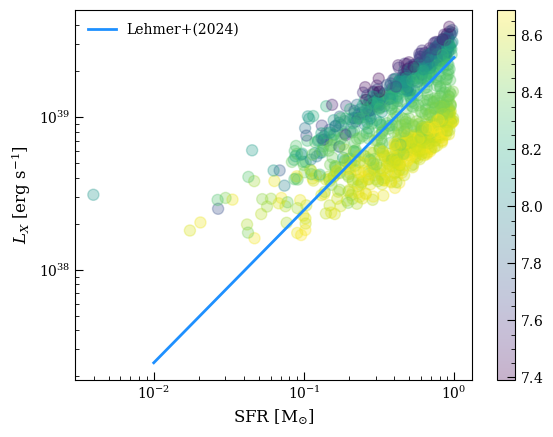

In [17]:
fig,ax = plt.subplots()
sfr = 0.1 * sfh_params[:,0] + 0.9 * sfh_params[:,1]

twelvelogOH = 8.69 + np.log10(Zvar_stellar_params[:,0] / 0.020)

pc = ax.scatter(
    sfr,
    LX_Zvar[:,2] * 3.848e33,
    marker='o',
    c=twelvelogOH,
    # facecolor='k',
    s=64,
    alpha=0.3
)

fig.colorbar(pc, ax=ax)

ax.plot(
    np.array([0.01, 1.0]),
    10**(39.39)*(np.array([0.01, 1.0])),
    color='dodgerblue',
    linewidth=2,
    label='Lehmer+(2024)'
)

ax.set_xlabel(r'SFR [$\rm M_{\odot}$]')
ax.set_ylabel(r'$L_X~[\rm erg~s^{-1}]$')

ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(loc='upper left')

print(
    np.quantile(
        LX[:,2] * 3.848e33 / sfr,
        q=(0.16, 0.50, 0.84)
    )
)

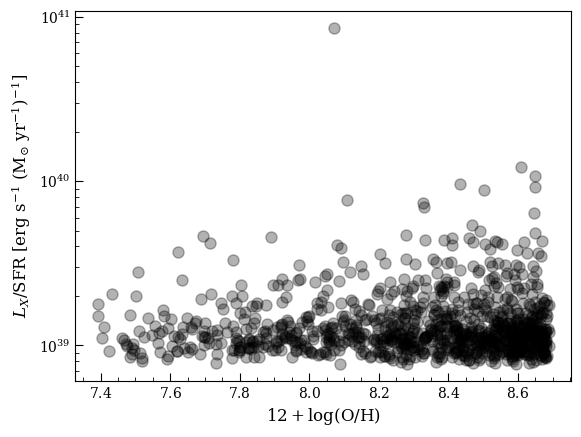

In [18]:
fig,ax = plt.subplots()
sfr = 0.1 * sfh_params[:,0] + 0.9 * sfh_params[:,1]

twelvelogOH = 8.69 + np.log10(Zvar_stellar_params[:,0] / 0.020)

pc = ax.scatter(
    twelvelogOH,
    LX[:,2] * 3.848e33 / sfr,
    marker='o',
    # c=twelvelogOH,
    facecolor='k',
    s=64,
    alpha=0.3
)

# fig.colorbar(ms, ax=ax)

# ax.plot(
#     np.array([0.01, 1.0]),
#     10**(39.39)*(np.array([0.01, 1.0])),
#     color='dodgerblue',
#     linewidth=2,
#     label='Lehmer+(2024)'
# )

ax.set_xlabel(r'$12 + \log(\rm O/H)$')
ax.set_ylabel(r'$L_X/{\rm SFR}~[\rm erg~s^{-1}~(M_{\odot}~yr^{-1})^{-1}]$')

# ax.set_xscale('log')
ax.set_yscale('log')

# ax.legend(loc='upper left')


## What about bursts? The LX-M$_\star$-Z-t relationship

We can make a grid of single age stellar populations at a few metallicities to plot LX/M vs t.

In [19]:
bpburst = BPASSBurstA24(
    filter_labels, redshift, XBPASS=True
)

# Solar, half-solar, tenth-solar
burst_params_Zsolar = np.tile(
    [0, 6, 0.02, -2],
    reps=(20,1)
)

burst_params_Zhalf = np.tile(
    [0, 6, 0.01, -2],
    reps=(20,1)
)
burst_params_Ztenth = np.tile(
    [0, 6, 0.002, -2],
    reps=(20,1)
)

agegrid = np.linspace(6,10, 20)

burst_params_Zsolar[:,1] = agegrid
burst_params_Zhalf[:,1] = agegrid
burst_params_Ztenth[:,1] = agegrid

In [20]:
LX_burst_Zsolar = bpburst.get_model_LX(
    burst_params_Zsolar
)

LX_burst_Zhalf = bpburst.get_model_LX(
    burst_params_Zhalf
)

LX_burst_Ztenth = bpburst.get_model_LX(
    burst_params_Ztenth
)

mstar_Zsolar = bpburst.get_mstar(
    burst_params_Zsolar
)

mstar_Zhalf = bpburst.get_mstar(
    burst_params_Zhalf
)

mstar_Ztenth = bpburst.get_mstar(
    burst_params_Ztenth
)

(6.7, 10.0)

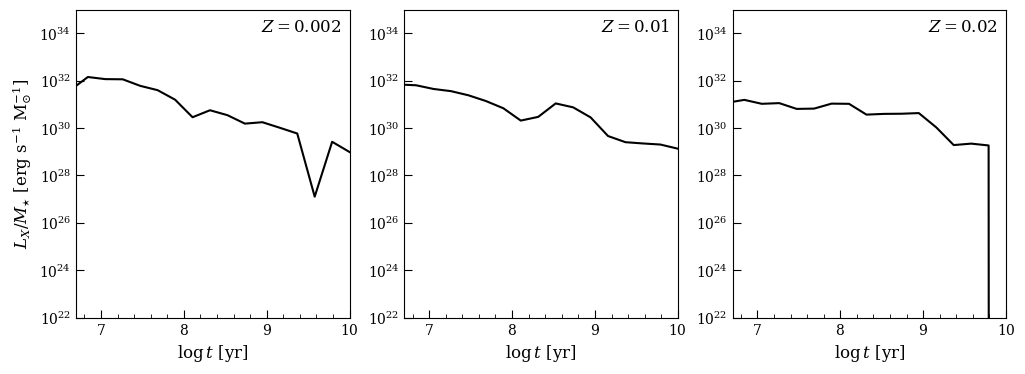

In [21]:
fig, axs = plt.subplots(1,3, figsize=(12,4))


axs[0].plot(
    agegrid,
    LX_burst_Ztenth[:,2].flatten() * 3.848e33 / mstar_Ztenth,
    marker='',
    linestyle='-',
    color='k'
)
axs[1].plot(
    agegrid,
    LX_burst_Zhalf[:,2].flatten() * 3.848e33 / mstar_Zhalf,
    marker='',
    linestyle='-',
    color='k'
)
axs[2].plot(
    agegrid,
    LX_burst_Zsolar[:,2].flatten() * 3.848e33 / mstar_Zsolar,
    marker='',
    linestyle='-',
    color='k'
)

axs[0].set_xlabel(r'$\log t~[\rm yr]$')
axs[1].set_xlabel(r'$\log t~[\rm yr]$')
axs[2].set_xlabel(r'$\log t~[\rm yr]$')
axs[0].set_ylabel(r'$L_X/M_{\star}~[\rm erg~s^{-1}~M_{\odot}^{-1}]$')
axs[0].text(
    0.97, 0.97,
    r'$Z=0.002$',
    transform=axs[0].transAxes,
    ha='right',
    va='top'
)
axs[1].text(
    0.97, 0.97,
    r'$Z=0.01$',
    transform=axs[1].transAxes,
    ha='right',
    va='top'
)
axs[2].text(
    0.97, 0.97,
    r'$Z=0.02$',
    transform=axs[2].transAxes,
    ha='right',
    va='top'
)
axs[0].set_yscale('log')
axs[1].set_yscale('log')
axs[2].set_yscale('log')
axs[0].set_ylim(1e22, 1e35)
axs[1].set_ylim(1e22, 1e35)
axs[2].set_ylim(1e22, 1e35)
axs[0].set_xlim(6.7, 10)
axs[1].set_xlim(6.7, 10)
axs[2].set_xlim(6.7, 10)

Compare this to e.g. Fragos+(2012): this is systematically a little lower. I'm unsure exactly why that would be; potentially assuming a later "turn-on" time for the first XRBs. The hard cut at $10^{9.8}$ years for solar metallicity is also interesting.